In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
fadata = cafe.data.read_pancreas()
fadata

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [7]:
import numpy as np
from scvelo.preprocessing.neighbors import get_neighs

np.min((get_neighs(fadata, "distances") > 0).sum(1).A1)

29

In [5]:
from cafe.method.function.preprocess_pipeline import preprocess_pipeline

preprocess_pipeline(fadata, style="scvelo")

WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                       

AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename', 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [ ]:
import scvelo as scv


scv.pp.

In [4]:
method = cafe.method.FateMethod("veloae")
method.infer_trajectory(fadata, parameters={"repreprocess": True})

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'veloae' is available: Python 3.10.18                                                                                                                                   
DEBUG    |- Loaded function 'veloae': <function veloae at 0x7093a9f2d7e0>                                                                                                                               
INFO     |- method backend loaded: CondaBackend: veloae in conda env 'veloae'                                                                                                                           
DEBUG    |- set new log file: ./.cafe/pancreas/log/20260206_124312__veloae-conda__UblDWn4plp.log                                                                                                    

DEBUG    |- extract 'clusters' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:20260206_122507__veloae-conda__JR5bhpEu1T, basis:X_umap.                                                                                  
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                               

array([[<Axes: title={'center': 'veloae-conda(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

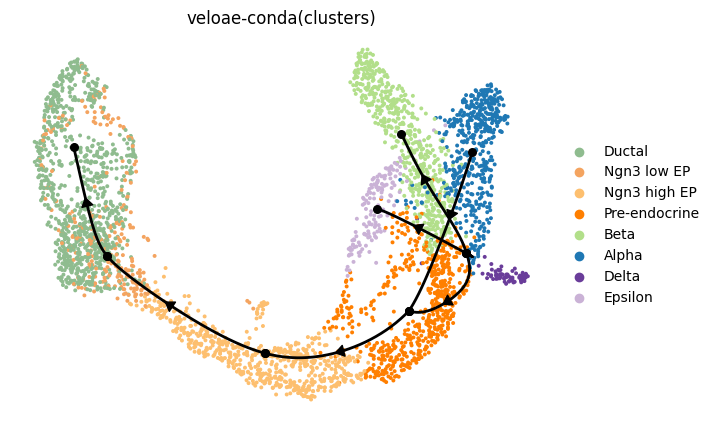

In [4]:
cafe.plot.plot_trajectory(fadata)